In [1]:
import pandas as pd 

train_df = pd.read_csv("iris_2class_train.csv")
test_df = pd.read_csv("iris_2class_test.csv")

train_df

,id,sepal length,sepal width,petal length,petal width,class
0,51,6.4,3.2,4.5,1.5,Iris-versicolor
1,99,5.7,2.8,4.1,1.3,Iris-versicolor
2,7,5.0,3.4,1.5,0.2,Iris-setosa
3,22,4.6,3.6,1.0,0.2,Iris-setosa
4,77,6.7,3.0,5.0,1.7,Iris-versicolor
...,...,...,...,...,...,...
65,63,6.1,2.9,4.7,1.4,Iris-versicolor
66,86,6.7,3.1,4.7,1.5,Iris-versicolor
67,1,4.9,3.0,1.4,0.2,Iris-setosa
68,14,5.8,4.0,1.2,0.2,Iris-setosa


In [2]:
test_df

,id,sepal length,sepal width,petal length,petal width,class
0,13,4.3,3.0,1.1,0.1,Iris-setosa
1,54,6.5,2.8,4.6,1.5,Iris-versicolor
2,2,4.7,3.2,1.3,0.2,Iris-setosa
3,59,5.2,2.7,3.9,1.4,Iris-versicolor
4,27,5.2,3.5,1.5,0.2,Iris-setosa
5,30,4.8,3.1,1.6,0.2,Iris-setosa
6,58,6.6,2.9,4.6,1.3,Iris-versicolor
7,87,6.3,2.3,4.4,1.3,Iris-versicolor
8,9,4.9,3.1,1.5,0.1,Iris-setosa
9,32,5.2,4.1,1.5,0.1,Iris-setosa


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('iris_2class_train.csv')
test  = pd.read_csv('iris_2class_test.csv')

feature_cols = ['sepal length', 'sepal width', 'petal length', 'petal width']

label_map = {'Iris-setosa': 0, 'Iris-versicolor': 1}

X_train = train[feature_cols].values.astype(float)
y_train = train['class'].map(label_map).values.astype(float)

X_test = test[feature_cols].values.astype(float)
y_test = test['class'].map(label_map).values.astype(float)

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

Xb_train = add_bias(X_train)
Xb_test  = add_bias(X_test)

n_train, n_features = Xb_train.shape  # n_features includes bias

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def compute_loss(X, y, w):
    """Binary cross-entropy loss (average over samples)."""
    m = X.shape[0]
    z = X @ w
    p = sigmoid(z)
    eps = 1e-12  # numerical stability
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    return loss

alpha = 0.1
n_iterations = 2000

w = np.zeros(n_features)  # w = [w0 (bias), w1, w2, w3, w4] initialized to 0
loss_history = []
loss_history.append(compute_loss(Xb_train, y_train, w))

m = n_train
for it in range(n_iterations):
    z = Xb_train @ w
    p = sigmoid(z)
    grad = (Xb_train.T @ (p - y_train)) / m
    w = w - alpha * grad
    loss_history.append(compute_loss(Xb_train, y_train, w))

print("Final weight vector:")
print(w)

print(f"\nFinal training loss (BCE): {loss_history[-1]:.6f}")
print(f"Initial training loss (BCE): {loss_history[0]:.6f}")

plt.figure(figsize=(7,5))
plt.plot(range(0, n_iterations+1), loss_history, color='#2563eb')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss History (Gradient Descent, α=0.1)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_history.png', dpi=150)
plt.close()

pd.DataFrame({'iteration': range(0, n_iterations+1), 'loss': loss_history}).to_csv(
    'loss_history.csv', index=False)

z_test = Xb_test @ w
p_test = sigmoid(z_test)
y_pred = (p_test >= 0.5).astype(int)

# ---------------------------------------------------------
# 5. Confusion Matrix & Accuracy
# ---------------------------------------------------------
# Convention: rows = actual, cols = predicted
# Order: 0 = Iris-setosa (negative), 1 = Iris-versicolor (positive)
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

confusion = np.array([[TN, FP],
                       [FN, TP]])

accuracy = (TP + TN) / len(y_test)

print("\nConfusion Matrix (rows=Actual, cols=Predicted)")
print("                 Pred: Setosa   Pred: Versicolor")
print(f"Actual: Setosa        {TN:^10d}   {FP:^15d}")
print(f"Actual: Versicolor    {FN:^10d}   {TP:^15d}")

print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Save confusion matrix plot
fig, ax = plt.subplots(figsize=(5,4.5))
im = ax.imshow(confusion, cmap='Blues')
labels = ['Setosa', 'Versicolor']
ax.set_xticks([0,1]); ax.set_xticklabels(labels)
ax.set_yticks([0,1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Accuracy = {accuracy*100:.2f}%)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(confusion[i, j]), ha='center', va='center',
                 color='white' if confusion[i,j] > confusion.max()/2 else 'black',
                 fontsize=16, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.close()

# Save results summary
with open('results_summary.txt', 'w') as f:
    f.write("Final weight vector:\n")
    f.write(f"{w}\n")
    f.write(f"\nFinal training loss: {loss_history[-1]:.6f}\n")
    f.write("\nConfusion Matrix (rows=Actual, cols=Predicted)\n")
    f.write("                 Pred: Setosa   Pred: Versicolor\n")
    f.write(f"Actual: Setosa        {TN:^10d}   {FP:^15d}\n")
    f.write(f"Actual: Versicolor    {FN:^10d}   {TP:^15d}\n")
    f.write(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print("\nSaved: loss_history.png, loss_history.csv, confusion_matrix.png, results_summary.txt")

Final weight vector:
[-0.38529074 -0.63670144 -2.29941137  3.55917287  1.59140886]

Final training loss (BCE): 0.004332
Initial training loss (BCE): 0.693147

Confusion Matrix (rows=Actual, cols=Predicted)
                 Pred: Setosa   Pred: Versicolor
Actual: Setosa            17              0       
Actual: Versicolor        0              13       

Accuracy: 1.0000 (100.00%)

Saved: loss_history.png, loss_history.csv, confusion_matrix.png, results_summary.txt


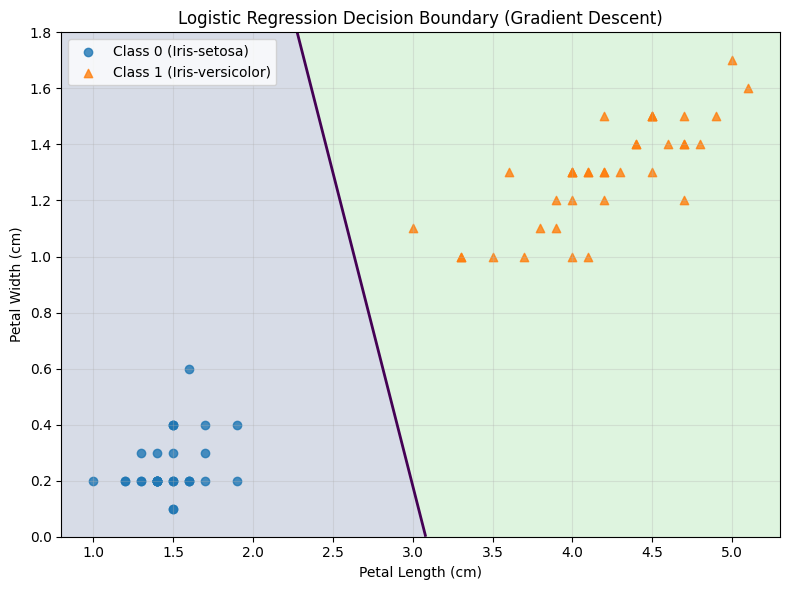

In [28]:
# ---------------------------------------------------------
# 6. Plot Classes and Decision Boundary
# ---------------------------------------------------------

# Feature indices
# 0 = sepal length
# 1 = sepal width
# 2 = petal length
# 3 = petal width

# Use petal length and petal width for visualization
x_feature = X_train[:, 2]   # petal length
y_feature = X_train[:, 3]   # petal width

# Create a grid for petal length and petal width
x_min = x_feature.min() - 0.2
x_max = x_feature.max() + 0.2
y_min = y_feature.min() - 0.1
y_max = y_feature.max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Keep sepal length and sepal width fixed at their mean
sepal_length_mean = X_train[:, 0].mean()
sepal_width_mean = X_train[:, 1].mean()

# Create grid data
grid = np.column_stack([
    np.full(xx.ravel().shape, sepal_length_mean),
    np.full(xx.ravel().shape, sepal_width_mean),
    xx.ravel(),
    yy.ravel()
])

# Add bias
grid_design = add_bias(grid)

# Calculate probabilities
grid_probability = sigmoid(grid_design @ w)

# Reshape probabilities to grid
grid_probability = grid_probability.reshape(xx.shape)


# ---------------------------------------------------------
# Plot decision regions
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(
    xx,
    yy,
    grid_probability,
    levels=[0, 0.5, 1],
    alpha=0.2
)

# Class 0
plt.scatter(
    X_train[y_train == 0, 2],
    X_train[y_train == 0, 3],
    label="Class 0 (Iris-setosa)",
    marker="o",
    alpha=0.8
)

# Class 1
plt.scatter(
    X_train[y_train == 1, 2],
    X_train[y_train == 1, 3],
    label="Class 1 (Iris-versicolor)",
    marker="^",
    alpha=0.8
)

# Decision boundary: probability = 0.5
plt.contour(
    xx,
    yy,
    grid_probability,
    levels=[0.5],
    linewidths=2
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.title(
    "Logistic Regression Decision Boundary "
    "(Gradient Descent)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "decision_boundary.png",
    dpi=150
)

plt.show()